---
title: "Monotone-spline CDFs"
short_title: "02 · Spline CDFs"
subtitle: "Monotone cubic CDFs, and the rational-quadratic spline with an exact analytic inverse"
description: >
  Splines give smooth, compact, learnable marginal transforms. Monotone cubic
  (PCHIP) interpolation keeps a CDF valid where a naive cubic overshoots; the
  rational-quadratic spline (Durkan 2019) is monotone by construction with a
  closed-form inverse and log-det — the gauss_flows RQSplineMarginal behind
  neural spline flows.
---

(sec-nb-mt-02)=
# 02 — Monotone-spline CDFs

The mixture CDF of [notebook 01](01_kde_mixture_cdf.ipynb) is smooth and
compact, but its inverse needs a root-find. **Splines** keep the smoothness and
compactness while buying something better: a parameterisation that is monotone
by construction and — for the right spline — invertible in *closed form*. That
is why splines are the marginal (and coupling) bijector of choice in modern
flows.

**What you will see**

- Why a CDF spline must be **monotone**, and how monotone cubic (PCHIP /
  Fritsch–Carlson) interpolation guarantees it where a naive cubic **overshoots**.
- The **rational-quadratic spline** (RQS): monotone by construction, with an
  **exact analytic inverse** and log-det — `gauss_flows.RQSplineMarginal`.
- Why "exact inverse" matters: machine-precision round-trip with **no
  iteration**, unlike the mixture-CDF root-find.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.interpolate import CubicSpline, PchipInterpolator

import gauss_flows as gf
import rbig
from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(12)

## 1. Monotonicity is the whole game

A CDF is non-decreasing, so any spline we use as a CDF **must** be monotone —
otherwise $F$ is not a valid CDF, $\Phi^{-1}(F(x))$ is multivalued, and the
transform is not invertible. Ordinary (natural) cubic splines do *not* respect
monotonicity: between knots they can **overshoot**, dipping below the data or
rising above it. **Monotone cubic Hermite** interpolation (Fritsch–Carlson
{cite}`fritsch1980monotone`, a.k.a. PCHIP) limits the knot slopes so the
interpolant stays monotone. Watch
both interpolate the *same* monotone CDF knots.

natural cubic: min=-0.0049, max=1.0049  (leaves [0,1] -> invalid CDF)
PCHIP:         min=0.0000, max=1.0000, monotone=True


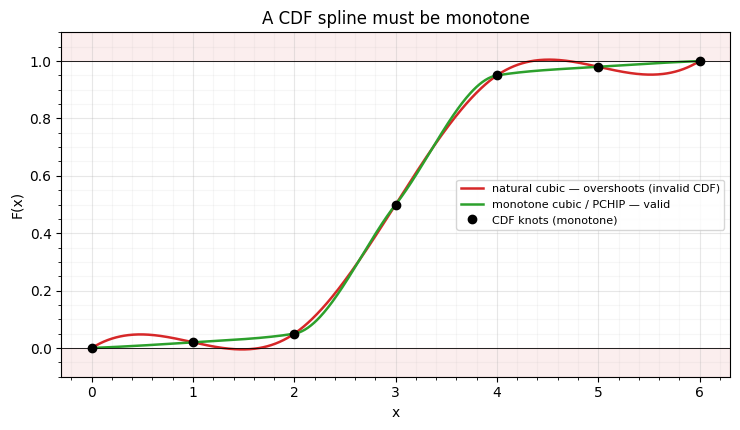

In [2]:
# Monotone CDF knots with a sharp central rise (flat -> steep -> flat).
t = np.array([0.0, 1, 2, 3, 4, 5, 6])
F = np.array([0.0, 0.02, 0.05, 0.5, 0.95, 0.98, 1.0])
tt = np.linspace(0, 6, 600)
pchip, cubic = PchipInterpolator(t, F), CubicSpline(t, F)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.axhspan(-0.1, 0, color="tab:red", alpha=0.08)
ax.axhspan(1, 1.1, color="tab:red", alpha=0.08)
ax.plot(tt, cubic(tt), color="tab:red", lw=1.8,
        label="natural cubic — overshoots (invalid CDF)")
ax.plot(tt, pchip(tt), color="tab:green", lw=1.8,
        label="monotone cubic / PCHIP — valid")
ax.plot(t, F, "ko", ms=6, label="CDF knots (monotone)")
ax.axhline(0, color="k", lw=0.6); ax.axhline(1, color="k", lw=0.6)
ax.set(title="A CDF spline must be monotone", xlabel="x", ylabel="F(x)",
       ylim=(-0.1, 1.1))
ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

print(f"natural cubic: min={cubic(tt).min():.4f}, max={cubic(tt).max():.4f}  "
      f"(leaves [0,1] -> invalid CDF)")
print(f"PCHIP:         min={pchip(tt).min():.4f}, max={pchip(tt).max():.4f}, "
      f"monotone={bool(np.all(np.diff(pchip(tt)) >= -1e-12))}")

The red natural cubic dips below $0$ and pokes above $1$ (shaded zones) — it is
not a CDF. The green PCHIP curve honours the same knots while staying inside
$[0,1]$ and monotone. A monotone-spline CDF Gaussianizer (e.g.
`rbig.SplineGaussianizer`, which fits a quantile spline) is built on exactly
this guarantee:

In [3]:
xg = rng.gamma(2.0, 1.0, size=(5000, 1))
sg = rbig.SplineGaussianizer().fit(xg)
zg = sg.transform(xg)
print(f"rbig.SplineGaussianizer on gamma data: output std = {zg.std():.3f}, "
      f"round-trip err = {np.abs(xg - sg.inverse_transform(zg)).max():.2e}")

rbig.SplineGaussianizer on gamma data: output std = 1.011, round-trip err = 3.33e-02


## 2. The rational-quadratic spline (RQS)

The monotone cubic is invertible, but only by root-find (it is a cubic). The
**rational-quadratic spline** {cite}`durkan2019nsf` is the modern alternative:
on each bin it is a ratio of quadratics,

$$
F(x) = \frac{\alpha\,\xi^2 + \beta\,\xi + \gamma}{a\,\xi^2 + b\,\xi + c},
\qquad \xi = \frac{x - x_k}{x_{k+1}-x_k},
$$

which is (i) **monotone by construction** for positive knot derivatives,
(ii) invertible in **closed form** — inverting it solves one quadratic per bin,
no iteration — and (iii) has an analytic log-det. Outside the spline interval it
falls back to identity (linear) tails. This is `gauss_flows.RQSplineMarginal`,
the bijector behind neural spline flows.

RQS exact-inverse round-trip: max err = 1.33e-15 (closed form, no iteration)
monotone forward: True


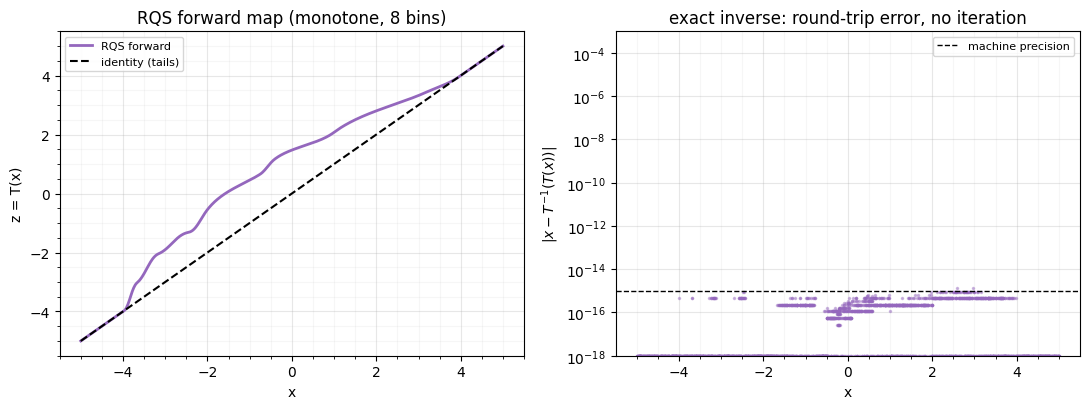

In [4]:
import equinox as eqx
import jax.random as jr

# RQSplineMarginal initialises at the identity (the right default for a flow
# layer — start as a no-op, then learn away). To show a non-trivial spline we
# perturb its unconstrained parameters; the softmax/softplus reparameterisation
# keeps the result monotone and exactly invertible.
b0 = gf.RQSplineMarginal(n_bins=8, shape=(1,), interval=4.0)
params, static = eqx.partition(b0, eqx.is_inexact_array)
keys = iter(jr.split(jr.key(3), 8))
params = jax.tree_util.tree_map(lambda a: a + 0.8 * jr.normal(next(keys), a.shape), params)
b = eqx.combine(params, static)

xs = jnp.linspace(-5, 5, 600)[:, None]
z, logdet = jax.vmap(b.transform_and_log_det)(xs)

# Exact-inverse round-trip on random inputs — no iteration.
xr_pts = jnp.asarray(rng.uniform(-5, 5, (3000, 1)))
zz = jax.vmap(b.transform)(xr_pts)
rt = jnp.abs(xr_pts - jax.vmap(b.inverse)(zz))
print(f"RQS exact-inverse round-trip: max err = {float(rt.max()):.2e} "
      f"(closed form, no iteration)")
print(f"monotone forward: {bool(jnp.all(jnp.diff(z.ravel()) >= -1e-9))}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(xs.ravel(), z.ravel(), color="tab:purple", lw=2, label="RQS forward")
axes[0].plot([-5, 5], [-5, 5], **GAUSS_KW, label="identity (tails)")
axes[0].set(title="RQS forward map (monotone, 8 bins)", xlabel="x", ylabel="z = T(x)")
axes[0].legend(fontsize=8); style_ax(axes[0])

axes[1].semilogy(xr_pts.ravel(), np.maximum(np.asarray(rt).ravel(), 1e-18), ".",
                 ms=3, alpha=0.4, color="tab:purple")
axes[1].axhline(1e-15, color="k", ls="--", lw=1, label="machine precision")
axes[1].set(title="exact inverse: round-trip error, no iteration",
            xlabel="x", ylabel=r"$|x - T^{-1}(T(x))|$", ylim=(1e-18, 1e-3))
axes[1].legend(fontsize=8); style_ax(axes[1])
fig.tight_layout()

The forward map is a smooth monotone S inside the interval and identity in the
tails; the inverse round-trips at machine precision *in one shot*. Contrast the
mixture-CDF of [notebook 01](01_kde_mixture_cdf.ipynb), which reaches the same
accuracy only after ~40 bisection steps — the RQS trades a slightly more complex
forward for a free, exact inverse. That asymmetry is why spline flows are the
default when you need fast sampling *and* fast density.

## 3. The Jacobian — an analytic log-determinant

A flow needs each layer's **log-determinant** $\log|T'(x)|$ (Part 0
[00](../00_foundations/00_change_of_variables.ipynb)). The RQS's third virtue —
after monotonicity and the exact inverse — is that this gradient is **analytic**:
on each bin $T$ is a ratio of quadratics, so $T'(x)$ is a closed-form rational
expression and $\log|T'| = \sum_{\text{bins}} \log T'$ needs no autodiff and no
quadrature. (For the monotone-cubic CDF the same role is played by the spline's
slope, $\mathrm{d}z/\mathrm{d}x = F'(x)/\varphi(z)$.) We plot the RQS Jacobian and
confirm `transform_and_log_det` matches an autodiff Jacobian.

analytic log|T'| vs autodiff: max|Δ| = 1.17e-15


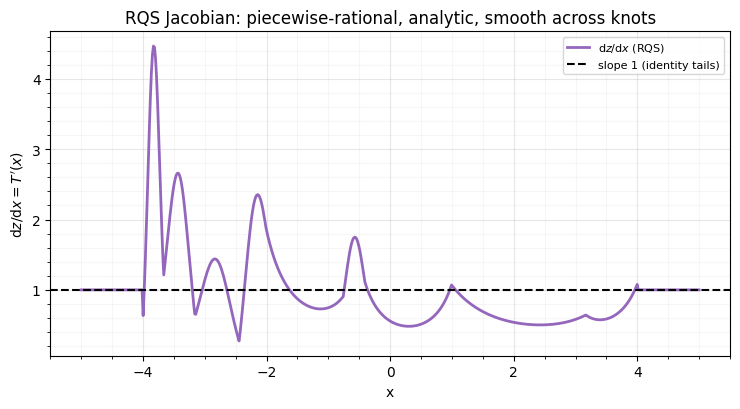

In [5]:
xj = jnp.linspace(-5, 5, 600)[:, None]
zj, logdet = jax.vmap(b.transform_and_log_det)(xj)            # b: perturbed RQS from §2
dzdx = jax.vmap(lambda v: jax.jacfwd(b.transform)(v).reshape(()))(xj)

print("analytic log|T'| vs autodiff: max|Δ| = "
      f"{float(jnp.max(jnp.abs(logdet - jnp.log(jnp.abs(dzdx))))):.2e}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(xj.ravel(), dzdx.ravel(), color="tab:purple", lw=2, label=r"$\mathrm{d}z/\mathrm{d}x$ (RQS)")
ax.axhline(1.0, **GAUSS_KW, label="slope 1 (identity tails)")
ax.set(title="RQS Jacobian: piecewise-rational, analytic, smooth across knots",
       xlabel="x", ylabel=r"$\mathrm{d}z/\mathrm{d}x = T'(x)$")
ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

The derivative is a smooth, strictly-positive curve inside the spline interval
(the rational-quadratic segments join $C^1$ at the knots) and flattens to slope
$1$ in the identity tails; `transform_and_log_det` reproduces it to machine
precision. An exact inverse *and* an exact log-det, both in closed form, is what
makes the RQS the workhorse coupling/marginal bijector of modern flows.

## Recap

| spline | monotone? | inverse | log-det | tool |
|---|---|---|---|---|
| natural cubic | ✗ (overshoots) | — | — | (don't use as CDF) |
| monotone cubic (PCHIP) | ✓ | root-find | numeric | `rbig.SplineGaussianizer` |
| rational-quadratic (RQS) | ✓ by construction | **closed form** | analytic | `gf.RQSplineMarginal` |

**Next up.** So far we have *fit* marginals by quantiles or EM. [03 — Mixture-CDF
as a learnable bijector](03_learnable_mixture_cdf.ipynb) trains the mixture-CDF
parameters end-to-end by maximum likelihood, and differentiates *through* its
root-find inverse with the implicit-function trick from Part 0.